<center> <img src = https://raw.githubusercontent.com/AndreyRysistov/DatasetsForPandas/main/hh%20label.jpg alt="drawing" style="width:400px;">

# <center> Проект: Анализ резюме из HeadHunter
   

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Исследование структуры данных

1. Прочитайте данные с помощью библиотеки Pandas. Совет: перед чтением обратите внимание на разделитель внутри файла. 

In [2]:
df = pd.read_csv(r"C:\Users\asus\Documents\study\hh_database.csv", sep=';')

2. Выведите несколько первых (последних) строк таблицы, чтобы убедиться в том, что ваши данные не повреждены. Ознакомьтесь с признаками и их структурой.

In [3]:
print(f"Первые 5 строк:")
print(df.head())

Первые 5 строк:
                                   Пол, возраст           ЗП  \
0    Мужчина ,  39 лет , родился 27 ноября 1979   29000 руб.   
1     Мужчина ,  60 лет , родился 20 марта 1959   40000 руб.   
2  Женщина ,  36 лет , родилась 12 августа 1982   20000 руб.   
3      Мужчина ,  38 лет , родился 25 июня 1980  100000 руб.   
4     Женщина ,  26 лет , родилась 3 марта 1993  140000 руб.   

                           Ищет работу на должность:  \
0                            Системный администратор   
1                               Технический писатель   
2                                           Оператор   
3  Веб-разработчик (HTML / CSS / JS / PHP / базы ...   
4                  Региональный менеджер по продажам   

                        Город, переезд, командировки  \
0  Советск (Калининградская область) , не готов к...   
1  Королев , не готов к переезду , готов к редким...   
2  Тверь , не готова к переезду , не готова к ком...   
3  Саратов , не готов к переезду , гот

3. Выведите основную информацию о числе непустых значений в столбцах и их типах в таблице.

4. Обратите внимание на информацию о числе непустых значений.

In [4]:
non_null_counts = df.count()
data_types = df.dtypes

info_summary = pd.DataFrame({
    'Non-Null Count': non_null_counts,
    'Dtype': data_types
})
print(info_summary)

                                 Non-Null Count   Dtype
Пол, возраст                              44744  object
ЗП                                        44744  object
Ищет работу на должность:                 44744  object
Город, переезд, командировки              44744  object
Занятость                                 44744  object
График                                    44744  object
Опыт работы                               44576  object
Последнее/нынешнее место работы           44743  object
Последняя/нынешняя должность              44742  object
Образование и ВУЗ                         44744  object
Обновление резюме                         44744  object
Авто                                      44744  object


5. Выведите основную статистическую информацию о столбцах.


In [5]:
print(df.describe())

                                         Пол, возраст          ЗП  \
count                                           44744       44744   
unique                                          16003         690   
top     Мужчина ,  32 года , родился 17 сентября 1986  50000 руб.   
freq                                               18        4064   

       Ищет работу на должность:  \
count                      44744   
unique                     14929   
top      Системный администратор   
freq                        3099   

                             Город, переезд, командировки         Занятость  \
count                                               44744             44744   
unique                                              10063                38   
top     Москва , не готов к переезду , не готов к кома...  полная занятость   
freq                                                 1261             30026   

             График                                        Опыт работы  \
cou

# Преобразование данных

1. Начнем с простого - с признака **"Образование и ВУЗ"**. Его текущий формат это: **<Уровень образования год выпуска ВУЗ специальность...>**. Например:
* Высшее образование 2016 Московский авиационный институт (национальный исследовательский университет)...
* Неоконченное высшее образование 2000  Балтийская государственная академия рыбопромыслового флота…
Нас будет интересовать только уровень образования.

Создайте с помощью функции-преобразования новый признак **"Образование"**, который должен иметь 4 категории: "высшее", "неоконченное высшее", "среднее специальное" и "среднее".

Выполните преобразование, ответьте на контрольные вопросы и удалите признак "Образование и ВУЗ".

Совет: обратите внимание на структуру текста в столбце **"Образование и ВУЗ"**. Гарантируется, что текущий уровень образования соискателя всегда находится в первых 2ух слов и начинается с заглавной буквы. Воспользуйтесь этим.

*Совет: проверяйте полученные категории, например, с помощью метода unique()*


In [6]:
df_processed = df.copy()

education_lambda = lambda x: (
    'неоконченное высшее' if str(x).startswith('Неоконченное высшее') else
    'высшее' if str(x).startswith('Высшее образование') else
    'среднее специальное' if str(x).startswith('Среднее специальное') else
    'среднее' if str(x).startswith('Среднее образование') else
    'среднее'  
)

df_processed['Образование'] = df_processed['Образование и ВУЗ'].apply(education_lambda)
df_processed = df_processed.drop('Образование и ВУЗ', axis=1)

2. Теперь нас интересует столбец **"Пол, возраст"**. Сейчас он представлен в формате **<Пол , возраст , дата рождения >**. Например:
* Мужчина , 39 лет , родился 27 ноября 1979 
* Женщина , 21 год , родилась 13 января 2000
Как вы понимаете, нам необходимо выделить каждый параметр в отдельный столбец.

Создайте два новых признака **"Пол"** и **"Возраст"**. При этом важно учесть:
* Признак пола должен иметь 2 уникальных строковых значения: 'М' - мужчина, 'Ж' - женщина. 
* Признак возраста должен быть представлен целыми числами.

Выполните преобразование, ответьте на контрольные вопросы и удалите признак **"Пол, возраст"** из таблицы.

*Совет: обратите внимание на структуру текста в столбце, в части на то, как разделены параметры пола, возраста и даты рождения между собой - символом ' , '. 
Гарантируется, что структура одинакова для всех строк в таблице. Вы можете воспользоваться этим.*


In [7]:
gender_lambda = lambda x: (
    'М' if str(x).split(' , ')[0].strip() == 'Мужчина' 
    else 'Ж' if str(x).split(' , ')[0].strip() == 'Женщина' 
    else None
)

age_lambda = lambda x: (
    int(''.join(filter(str.isdigit, str(x).split(' , ')[1].strip()))) 
    if len(str(x).split(' , ')) > 1 
    else None
)

df_processed['Пол'] = df_processed['Пол, возраст'].apply(gender_lambda)
df_processed['Возраст'] = df_processed['Пол, возраст'].apply(age_lambda)


gender_distribution = df_processed['Пол'].value_counts()
total_with_gender = gender_distribution.sum()
female_percentage = (gender_distribution.get('Ж', 0) / total_with_gender) * 100
print(f"Женские резюме: {gender_distribution.get('Ж', 0)} ({female_percentage:.2f}%)")

mean_age = df_processed['Возраст'].mean()
print(f"Средний возраст соискателей: {mean_age:.2f} лет")

df_processed = df_processed.drop('Пол, возраст', axis=1)
print(f"\nСтолбцы в обработанном датасете: {df_processed.columns.tolist()}")


Женские резюме: 8533 (19.07%)
Средний возраст соискателей: 32.20 лет

Столбцы в обработанном датасете: ['ЗП', 'Ищет работу на должность:', 'Город, переезд, командировки', 'Занятость', 'График', 'Опыт работы', 'Последнее/нынешнее место работы', 'Последняя/нынешняя должность', 'Обновление резюме', 'Авто', 'Образование', 'Пол', 'Возраст']


3. Следующим этапом преобразуем признак **"Опыт работы"**. Его текущий формат - это: **<Опыт работы: n лет m месяцев, периоды работы в различных компаниях…>**. 

Из столбца нам необходимо выделить общий опыт работы соискателя в месяцах, новый признак назовем "Опыт работы (месяц)"

Для начала обсудим условия решения задачи:
* Во-первых, в данном признаке есть пропуски. Условимся, что если мы встречаем пропуск, оставляем его как есть (функция-преобразование возвращает NaN)
* Во-вторых, в данном признаке есть скрытые пропуски. Для некоторых соискателей в столбце стоит значения "Не указано". Их тоже обозначим как NaN (функция-преобразование возвращает NaN)
* В-третьих, нас не интересует информация, которая описывается после указания опыта работы (периоды работы в различных компаниях)
* В-четвертых, у нас есть проблема: опыт работы может быть представлен только в годах или только месяцах. Например, можно встретить следующие варианты:
    * Опыт работы 3 года 2 месяца…
    * Опыт работы 4 года…
    * Опыт работы 11 месяцев…
    * Учитывайте эту особенность в вашем коде

Учитывайте эту особенность в вашем коде

В результате преобразования у вас должен получиться столбец, содержащий информацию о том, сколько месяцев проработал соискатель.
Выполните преобразование, ответьте на контрольные вопросы и удалите столбец **"Опыт работы"** из таблицы.


In [8]:
convert_experience = lambda x: (
    np.nan if (pd.isna(x) or str(x).strip() == 'Не указано') else
    (lambda s: (
        # Поиск лет
        (lambda: next((int(word) for i, word in enumerate(s.split()) 
                      if word.isdigit() and i < len(s.split())-1 
                      and any(y in s.split()[i+1].lower() for y in ['год', 'лет', 'года'])), 0))() * 12 +
        # Поиск месяцев
        (lambda: next((int(word) for i, word in enumerate(s.split()) 
                      if word.isdigit() and i < len(s.split())-1 
                      and any(m in s.split()[i+1].lower() for m in ['месяц', 'месяца', 'месяцев'])), 0))()
    ))(str(x).lower())
)
df_processed['Опыт работы (месяц)'] = df_processed['Опыт работы'].apply(convert_experience)
df_processed = df_processed.drop('Опыт работы', axis=1)
print(f"\nСтолбцы в обработанном датасете: {df_processed.columns.tolist()}")



Столбцы в обработанном датасете: ['ЗП', 'Ищет работу на должность:', 'Город, переезд, командировки', 'Занятость', 'График', 'Последнее/нынешнее место работы', 'Последняя/нынешняя должность', 'Обновление резюме', 'Авто', 'Образование', 'Пол', 'Возраст', 'Опыт работы (месяц)']


4. Хорошо идем! Следующий на очереди признак "Город, переезд, командировки". Информация в нем представлена в следующем виде: **<Город , (метро) , готовность к переезду (города для переезда) , готовность к командировкам>**. В скобках указаны необязательные параметры строки. Например, можно встретить следующие варианты:

* Москва , не готов к переезду , готов к командировкам
* Москва , м. Беломорская , не готов к переезду, не готов к командировкам
* Воронеж , готов к переезду (Сочи, Москва, Санкт-Петербург) , готов к командировкам

Создадим отдельные признаки **"Город"**, **"Готовность к переезду"**, **"Готовность к командировкам"**. При этом важно учесть:

* Признак **"Город"** должен содержать только 4 категории: "Москва", "Санкт-Петербург" и "город-миллионник" (их список ниже), остальные обозначьте как "другие".

    Список городов-миллионников:
    
   <code>million_cities = ['Новосибирск', 'Екатеринбург','Нижний Новгород','Казань', 'Челябинск','Омск', 'Самара', 'Ростов-на-Дону', 'Уфа', 'Красноярск', 'Пермь', 'Воронеж','Волгоград']
    </code>
    Инфорация о метро, рядом с которым проживает соискатель нас не интересует.
* Признак **"Готовность к переезду"** должен иметь два возможных варианта: True или False. Обратите внимание, что возможны несколько вариантов описания готовности к переезду в признаке "Город, переезд, командировки". Например:
    * … , готов к переезду , …
    * … , не готова к переезду , …
    * … , готова к переезду (Москва, Санкт-Петербург, Ростов-на-Дону)
    * … , хочу переехать (США) , …
    
    Нас интересует только сам факт возможности или желания переезда.
* Признак **"Готовность к командировкам"** должен иметь два возможных варианта: True или False. Обратите внимание, что возможны несколько вариантов описания готовности к командировкам в признаке "Город, переезд, командировки". Например:
    * … , готов к командировкам , … 
    * … , готова к редким командировкам , …
    * … , не готов к командировкам , …
    
    Нас интересует только сам факт готовности к командировке.
    
    Еще один важный факт: при выгрузки данных у некоторых соискателей "потерялась" информация о готовности к командировкам. Давайте по умолчанию будем считать, что такие соискатели не готовы к командировкам.
    
Выполните преобразования и удалите столбец **"Город, переезд, командировки"** из таблицы.

*Совет: обратите внимание на то, что структура текста может меняться в зависимости от указания ближайшего метро. Учите это, если будете использовать порядок слов в своей программе.*


In [9]:
million_cities = ['Новосибирск', 'Екатеринбург', 'Нижний Новгород', 'Казань', 'Челябинск', 
                  'Омск', 'Самара', 'Ростов-на-Дону', 'Уфа', 'Красноярск', 'Пермь', 
                  'Воронеж', 'Волгоград']

extract_city_lambda = lambda x: (
    'Москва' if 'Москва' in str(x).split(' , ')[0] else
    'Санкт-Петербург' if 'Санкт-Петербург' in str(x).split(' , ')[0] else
    'город-миллионник' if any(city in str(x).split(' , ')[0] for city in million_cities) else
    'другие'
)

df_processed['Город'] = df_processed['Город, переезд, командировки'].apply(extract_city_lambda)

spb_count = (df_processed['Город'] == 'Санкт-Петербург').sum()
total_with_city = df_processed['Город'].count()
spb_percentage = (spb_count / total_with_city) * 100
print(f"Процент соискателей в Санкт-Петербурге: {spb_percentage:.1f}%")

relocation_negative = ['не готов к переезду', 'не готова к переезду']
extract_relocation_lambda = lambda x: (
    False if pd.isna(x) else (False if any(ind in str(x).lower() for ind in relocation_negative) else True)
)

business_negative = ['не готов к командировкам', 'не готова к командировкам']
extract_business_trips_lambda = lambda x: (
    False if pd.isna(x) else (False if any(ind in str(x).lower() for ind in business_negative) else True)
)

df_processed['Город'] = df_processed['Город, переезд, командировки'].apply(extract_city_lambda)
df_processed['Готовность к переезду'] = df_processed['Город, переезд, командировки'].apply(extract_relocation_lambda)
df_processed['Готовность к командировкам'] = df_processed['Город, переезд, командировки'].apply(extract_business_trips_lambda)
both_ready_percentage = round(((df_processed['Готовность к переезду']) & (df_processed['Готовность к командировкам'])).mean() * 100)
print(f"Процент готовых и к переезду, и к командировкам: {both_ready_percentage}%")

df_processed = df_processed.drop('Город, переезд, командировки', axis=1)
print(f"\nИтоговые столбцы: {df_processed.columns.tolist()}")



Процент соискателей в Санкт-Петербурге: 11.0%
Процент готовых и к переезду, и к командировкам: 32%

Итоговые столбцы: ['ЗП', 'Ищет работу на должность:', 'Занятость', 'График', 'Последнее/нынешнее место работы', 'Последняя/нынешняя должность', 'Обновление резюме', 'Авто', 'Образование', 'Пол', 'Возраст', 'Опыт работы (месяц)', 'Город', 'Готовность к переезду', 'Готовность к командировкам']


5. Рассмотрим поближе признаки **"Занятость"** и **"График"**. Сейчас признаки представляют собой набор категорий желаемой занятости (полная занятость, частичная занятость, проектная работа, волонтерство, стажировка) и желаемого графика работы (полный день, сменный график, гибкий график, удаленная работа, вахтовый метод).
На сайте hh.ru соискатель может указывать различные комбинации данных категорий, например:
* полная занятость, частичная занятость
* частичная занятость, проектная работа, волонтерство
* полный день, удаленная работа
* вахтовый метод, гибкий график, удаленная работа, полная занятость

Такой вариант признаков имеет множество различных комбинаций, а значит множество уникальных значений, что мешает анализу. Нужно это исправить!

Давайте создадим признаки-мигалки для каждой категории: если категория присутствует в списке желаемых соискателем, то в столбце на месте строки рассматриваемого соискателя ставится True, иначе - False.

Такой метод преобразования категориальных признаков называется One Hot Encoding и его схема представлена на рисунке ниже:
<img src=https://raw.githubusercontent.com/AndreyRysistov/DatasetsForPandas/main/ohe.jpg>
Выполните данное преобразование для признаков "Занятость" и "График", ответьте на контрольные вопросы, после чего удалите их из таблицы

In [10]:
employment_categories = ['полная занятость', 'частичная занятость', 'проектная работа', 'волонтерство', 'стажировка']
schedule_categories = ['полный день', 'сменный график', 'гибкий график', 'удалённая работа', 'вахтовый метод']

employment_lambda = lambda x: {category: category in str(x).lower() for category in employment_categories} if not pd.isna(x) else {category: False for category in employment_categories}
schedule_lambda = lambda x: {category: category in str(x).lower() for category in schedule_categories} if not pd.isna(x) else {category: False for category in schedule_categories}

employment_ohe = df_processed['Занятость'].apply(employment_lambda)
for category in employment_categories:
    df_processed[f'Занятость_{category}'] = employment_ohe.apply(lambda x: x[category])

schedule_ohe = df_processed['График'].apply(schedule_lambda)
for category in schedule_categories:
    df_processed[f'График_{category}'] = schedule_ohe.apply(lambda x: x[category])


project_volunteer = ((df_processed['Занятость_проектная работа'] == True) & 
                     (df_processed['Занятость_волонтерство'] == True)).sum()

shift_flexible = ((df_processed['График_вахтовый метод'] == True) & 
                  (df_processed['График_гибкий график'] == True)).sum()

print(f"Людей, ищущих проектную работу и волонтерство: {project_volunteer}")
print(f"Людей, которые хотят вахтовый метод и гибкий график: {shift_flexible}")
df_processed = df_processed.drop(['Занятость', 'График'], axis=1)
print(f"\nИтоговые столбцы: {df_processed.columns.tolist()}")

Людей, ищущих проектную работу и волонтерство: 436
Людей, которые хотят вахтовый метод и гибкий график: 2311

Итоговые столбцы: ['ЗП', 'Ищет работу на должность:', 'Последнее/нынешнее место работы', 'Последняя/нынешняя должность', 'Обновление резюме', 'Авто', 'Образование', 'Пол', 'Возраст', 'Опыт работы (месяц)', 'Город', 'Готовность к переезду', 'Готовность к командировкам', 'Занятость_полная занятость', 'Занятость_частичная занятость', 'Занятость_проектная работа', 'Занятость_волонтерство', 'Занятость_стажировка', 'График_полный день', 'График_сменный график', 'График_гибкий график', 'График_удалённая работа', 'График_вахтовый метод']


6. (2 балла) Наконец, мы добрались до самого главного и самого важного - признака заработной платы **"ЗП"**. 
В чем наша беда? В том, что помимо желаемой заработной платы соискатель указывает валюту, в которой он бы хотел ее получать, например:
* 30000 руб.
* 50000 грн.
* 550 USD

Нам бы хотелось видеть заработную плату в единой валюте, например, в рублях. Возникает вопрос, а где взять курс валют по отношению к рублю?

На самом деле язык Python имеет в арсенале огромное количество возможностей получения данной информации, от обращения к API Центробанка, до использования специальных библиотек, например pycbrf. Однако, это не тема нашего проекта.

Поэтому мы пойдем в лоб: обратимся к специальным интернет-ресурсам для получения данных о курсе в виде текстовых файлов. Например, MDF.RU, данный ресурс позволяет удобно экспортировать данные о курсах различных валют и акций за указанные периоды в виде csv файлов. Мы уже сделали выгрузку курсов валют, которые встречаются в наших данных за период с 29.12.2017 по 05.12.2019. Скачать ее вы можете **на платформе**

Создайте новый DataFrame из полученного файла. В полученной таблице нас будут интересовать столбцы:
* "currency" - наименование валюты в ISO кодировке,
* "date" - дата, 
* "proportion" - пропорция, 
* "close" - цена закрытия (последний зафиксированный курс валюты на указанный день).


Перед вами таблица соответствия наименований иностранных валют в наших данных и их общепринятых сокращений, которые представлены в нашем файле с курсами валют. Пропорция - это число, за сколько единиц валюты указан курс в таблице с курсами. Например, для казахстанского тенге курс на 20.08.2019 составляет 17.197 руб. за 100 тенге, тогда итоговый курс равен - 17.197 / 100 = 0.17197 руб за 1 тенге.
Воспользуйтесь этой информацией в ваших преобразованиях.

<img src=https://raw.githubusercontent.com/AndreyRysistov/DatasetsForPandas/main/table.jpg>


Осталось только понять, откуда брать дату, по которой определяется курс? А вот же она - в признаке **"Обновление резюме"**, в нем содержится дата и время, когда соискатель выложил текущий вариант своего резюме. Нас интересует только дата, по ней бы и будем сопоставлять курсы валют.

Теперь у нас есть вся необходимая информация для того, чтобы создать признак "ЗП (руб)" - заработная плата в рублях.

После ответа на контрольные вопросы удалите исходный столбец заработной платы "ЗП" и все промежуточные столбцы, если вы их создавали.

Итак, давайте обсудим возможный алгоритм преобразования: 
1. Перевести признак "Обновление резюме" из таблицы с резюме в формат datetime и достать из него дату. В тот же формат привести признак "date" из таблицы с валютами.
2. Выделить из столбца "ЗП" сумму желаемой заработной платы и наименование валюты, в которой она исчисляется. Наименование валюты перевести в стандарт ISO согласно с таблицей выше.
3. Присоединить к таблице с резюме таблицу с курсами по столбцам с датой и названием валюты (подумайте, какой тип объединения надо выбрать, чтобы в таблице с резюме сохранились данные о заработной плате, изначально представленной в рублях). Значение close для рубля заполнить единицей 1 (курс рубля самого к себе)
4. Умножить сумму желаемой заработной платы на присоединенный курс валюты (close) и разделить на пропорцию (обратите внимание на пропуски после объединения в этих столбцах), результат занести в новый столбец "ЗП (руб)".


In [11]:
currency_rates = pd.read_csv(r"C:\Users\asus\Documents\study\ExchangeRates.csv", sep=',')
currency_rates['date'] = pd.to_datetime(currency_rates['date'], format='%d/%m/%y')

currency_mapping = {
    'грн': ('UAH', 10),
    'usd': ('USD', 1),
    'eur': ('EUR', 1),
    'белруб': ('BYN', 1),
    'kgs': ('KGS', 10),
    'сум': ('UZS', 10000),
    'azn': ('AZN', 1),
    'kzt': ('KZT', 100),
    'руб': ('RUB', 1)
}

extract_salary_lambda = lambda x: (
    (float(''.join(filter(str.isdigit, str(x)))), 
     ''.join(filter(str.isalpha, str(x).split()[-1])).lower()) 
    if not pd.isna(x) and any(char.isdigit() for char in str(x)) 
    else (None, None)
)

get_currency_iso_lambda = lambda x: currency_mapping.get(x, (None, None))[0] if x else None
get_proportion_lambda = lambda x: currency_mapping.get(x, (None, None))[1] if x else None

df_processed['Дата_обновления'] = pd.to_datetime(df_processed['Обновление резюме'], format='%d.%m.%Y %H:%M').dt.date
df_processed['Дата_обновления'] = pd.to_datetime(df_processed['Дата_обновления'])

df_processed[['ЗП_сумма', 'ЗП_валюта']] = df_processed['ЗП'].apply(lambda x: pd.Series(extract_salary_lambda(x)))
df_processed['Валюта_ISO'] = df_processed['ЗП_валюта'].apply(get_currency_iso_lambda)
df_processed['Пропорция'] = df_processed['ЗП_валюта'].apply(get_proportion_lambda)

df_processed = df_processed.merge(
    currency_rates[['currency', 'date', 'close']],
    left_on=['Валюта_ISO', 'Дата_обновления'],
    right_on=['currency', 'date'],
    how='left'
)

df_processed.loc[df_processed['Валюта_ISO'] == 'RUB', 'close'] = 1.0

df_processed['ЗП (руб)'] = df_processed.apply(
    lambda row: row['ЗП_сумма'] * row['close'] / row['Пропорция'] 
    if not pd.isna(row['ЗП_сумма']) and not pd.isna(row['close']) and not pd.isna(row['Пропорция']) 
    else None, 
    axis=1
)

columns_to_drop = ['ЗП', 'ЗП_сумма', 'ЗП_валюта', 'Валюта_ISO', 'Пропорция', 
                   'currency', 'date', 'close', 'Дата_обновления', 'Обновление резюме']
df_processed = df_processed.drop(columns=[col for col in columns_to_drop if col in df_processed.columns])

print(f"Итоговые столбцы: {df_processed.columns.tolist()}")


Итоговые столбцы: ['Ищет работу на должность:', 'Последнее/нынешнее место работы', 'Последняя/нынешняя должность', 'Авто', 'Образование', 'Пол', 'Возраст', 'Опыт работы (месяц)', 'Город', 'Готовность к переезду', 'Готовность к командировкам', 'Занятость_полная занятость', 'Занятость_частичная занятость', 'Занятость_проектная работа', 'Занятость_волонтерство', 'Занятость_стажировка', 'График_полный день', 'График_сменный график', 'График_гибкий график', 'График_удалённая работа', 'График_вахтовый метод', 'ЗП (руб)']


# Исследование зависимостей в данных

1. Постройте распределение признака **"Возраст"**. Опишите распределение, отвечая на следующие вопросы: чему равна мода распределения, каковы предельные значения признака, в каком примерном интервале находится возраст большинства соискателей? Есть ли аномалии для признака возраста, какие значения вы бы причислили к их числу?
*Совет: постройте гистограмму и коробчатую диаграмму рядом.*

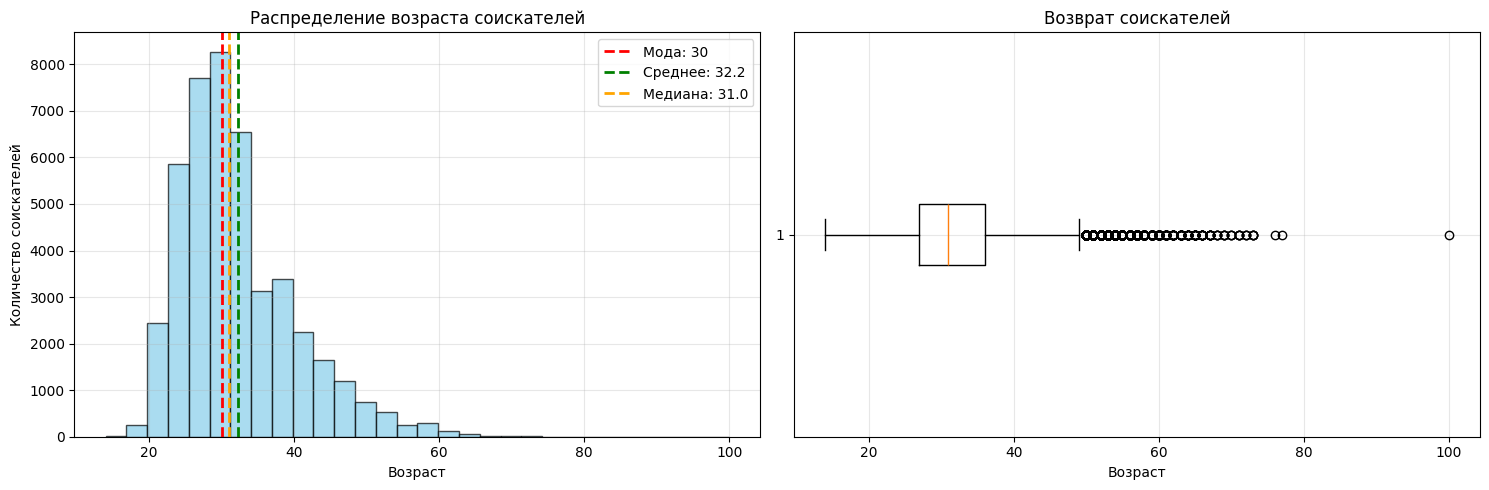

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Гистограмма
ax1.hist(df_processed['Возраст'].dropna(), bins=30, edgecolor='black', alpha=0.7, color='skyblue')
ax1.axvline(df_processed['Возраст'].mode()[0], color='red', linestyle='--', linewidth=2, label=f'Мода: {df_processed["Возраст"].mode()[0]}')
ax1.axvline(df_processed['Возраст'].mean(), color='green', linestyle='--', linewidth=2, label=f'Среднее: {df_processed["Возраст"].mean():.1f}')
ax1.axvline(df_processed['Возраст'].median(), color='orange', linestyle='--', linewidth=2, label=f'Медиана: {df_processed["Возраст"].median():.1f}')
ax1.set_xlabel('Возраст')
ax1.set_ylabel('Количество соискателей')
ax1.set_title('Распределение возраста соискателей')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Boxplot
ax2.boxplot(df_processed['Возраст'].dropna(), vert=False)
ax2.set_xlabel('Возраст')
ax2.set_title('Bозврат соискателей')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


На представленной гистограмме показано распределение возрастов соискателей, а также выделены основные статистические характеристики — мода, среднее и медиана. Мода распределения составляет 30 лет, то есть именно этот возраст встречается чаще всего. Среднее значение равно 32.2 года, а медиана — 31 год, что свидетельствует о достаточно симметричном распределении без выраженного смещения в одну из сторон. Большинство соискателей находятся в возрасте от 25 до 40 лет — именно в этом интервале наблюдается наибольшая концентрация данных. Возрастные границы признака варьируются примерно от 18 до 100 лет, однако основная масса значений сосредоточена в пределах трудоспособного возраста. На коробчатой диаграмме можно заметить несколько отдельных точек, расположенных справа за пределами «усов». Эти значения соответствуют возрастам старше примерно 60 лет и являются аномалиями (выбросами), так как существенно отличаются от основной части выборки.

2. Постройте распределение признака **"Опыт работы (месяц)"**. Опишите данное распределение, отвечая на следующие вопросы: чему равна мода распределения, каковы предельные значения признака, в каком примерном интервале находится опыт работы большинства соискателей? Есть ли аномалии для признака опыта работы, какие значения вы бы причислили к их числу?
*Совет: постройте гистограмму и коробчатую диаграмму рядом.*

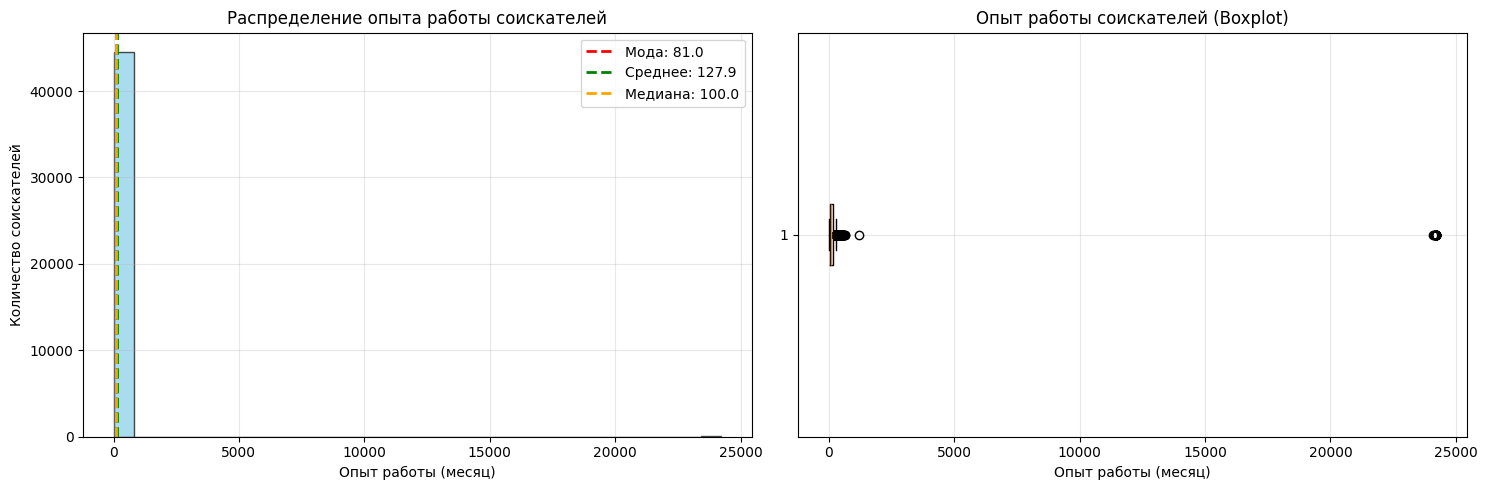

Максимальный опыт работы: 24230.0 месяцев


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.hist(df_processed['Опыт работы (месяц)'].dropna(), bins=30, edgecolor='black', alpha=0.7, color='skyblue')
ax1.axvline(df_processed['Опыт работы (месяц)'].mode()[0], color='red', linestyle='--', linewidth=2, label=f'Мода: {df_processed["Опыт работы (месяц)"].mode()[0]}')
ax1.axvline(df_processed['Опыт работы (месяц)'].mean(), color='green', linestyle='--', linewidth=2, label=f'Среднее: {df_processed["Опыт работы (месяц)"].mean():.1f}')
ax1.axvline(df_processed['Опыт работы (месяц)'].median(), color='orange', linestyle='--', linewidth=2, label=f'Медиана: {df_processed["Опыт работы (месяц)"].median():.1f}')
ax1.set_xlabel('Опыт работы (месяц)')
ax1.set_ylabel('Количество соискателей')
ax1.set_title('Распределение опыта работы соискателей')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.boxplot(df_processed['Опыт работы (месяц)'].dropna(), vert=False)
ax2.set_xlabel('Опыт работы (месяц)')
ax2.set_title('Опыт работы соискателей (Boxplot)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

max_experience = df_processed['Опыт работы (месяц)'].max()
print(f'Максимальный опыт работы: {max_experience} месяцев')


На графиках представлено распределение признака "Опыт работы (месяц)". Мода распределения составляет 81 месяц, что эквивалентно примерно 6,5 годам. Это значение встречается чаще всего и отражает наиболее типичный опыт работы среди кандидатов. Среднее значение равно 127,9 месяца (около 10,5 лет), а медиана — 100 месяцев (примерно 8,3 года). Разница между средним и медианой указывает на смещённое вправо распределение, где небольшое количество соискателей с очень большим стажем существенно увеличивает среднее значение. Большинство соискателей имеют опыт работы в пределах от 0 до 200 месяцев (до 16–17 лет), и именно этот диапазон является наиболее характерным для выборки. Однако на графике заметно наличие аномальных значений — отдельные точки на boxplot указывают на экстремальные выбросы. Максимальный опыт работы равен 24 230 месяцев, что соответствует более чем 2 000 годам, и, очевидно, является ошибкой ввода данных. Эти значения нельзя считать реалистичными и их стоит отнести к выбросам, подлежащим очистке из выборки.

3. Постройте распределение признака **"ЗП (руб)"**. Опишите данное распределение, отвечая на следующие вопросы: каковы предельные значения признака, в каком примерном интервале находится заработная плата большинства соискателей? Есть ли аномалии для признака возраста? Обратите внимание на гигантские размеры желаемой заработной платы.
*Совет: постройте гистограмму и коробчатую диаграмму рядом.*


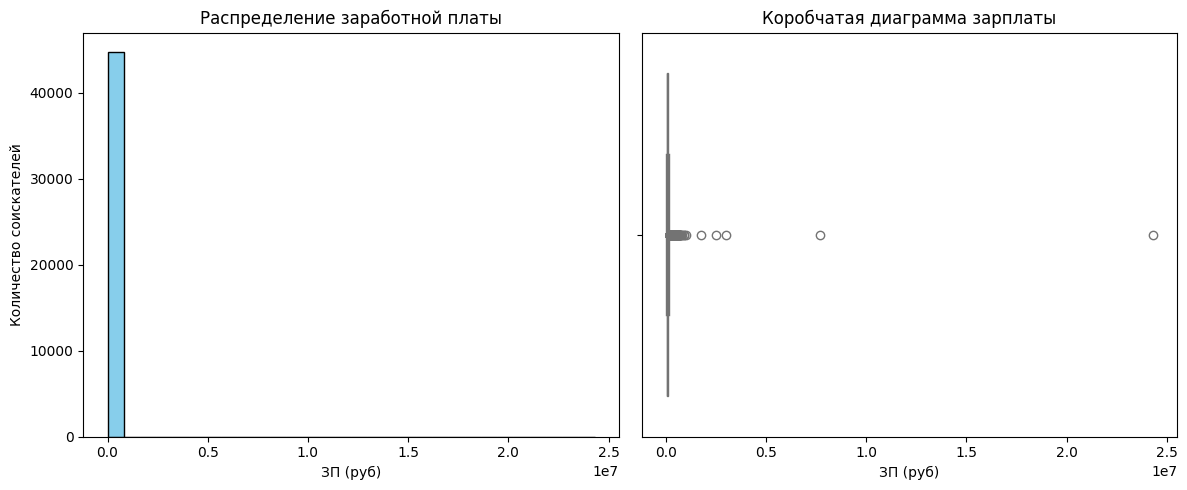

In [ ]:
plt.figure(figsize=(12,5))

calculate_stats_lambda = lambda data: (
    data.mode()[0] if len(data.mode()) > 0 else None,
    data.min(),
    data.max(),
    data.quantile(0.25),
    data.quantile(0.75),
    data.quantile(0.75) - data.quantile(0.25)
)

find_outliers_lambda = lambda data, q1, q3: (
    data[(data < (q1 - 1.5 * (q3 - q1))) | (data > (q3 + 1.5 * (q3 - q1)))]
)

# Применяем lambda-функции к данным зарплаты
mode_salary, min_salary, max_salary, q1_salary, q3_salary, iqr_salary = calculate_stats_lambda(df_processed['ЗП (руб)'].dropna())
outliers_salary = find_outliers_lambda(df_processed['ЗП (руб)'].dropna(), q1_salary, q3_salary)

# Считаем соискателей с зарплатой выше 1 млн рублей
high_salary_count = (df_processed['ЗП (руб)'] > 1000000).sum()

plt.subplot(1,2,1)
plt.hist(df_processed['ЗП (руб)'], bins=30, color='skyblue', edgecolor='black')
plt.title('Распределение заработной платы')
plt.xlabel('ЗП (руб)')
plt.ylabel('Количество соискателей')

plt.subplot(1,2,2)
sns.boxplot(x=df_processed['ЗП (руб)'], color='lightgreen')
plt.title('Коробчатая диаграмма зарплаты')

plt.tight_layout()
plt.show()


На графиках представлено распрежеление признака "ЗП". Мода распределения равна 50 тысячам рублей при предельных значениях признака от 1 до до 24 304 876 рублей, что само по себе нереалистично, при этом интервал большинства соискателей находится в пределах 37 082 до 95 000 рублей. Наличие аномалий наглядно видно на графике коробчатой диаграммы — отдельные точки с правой стороны указывают на экстремальные значения пожеланий в вопросе заработной платы. Выбросы, относящиеся к запросам зарплаты свыше 1 миллиона рублей, значительно искажают визуализацию.

4. Постройте диаграмму, которая показывает зависимость **медианной** желаемой заработной платы (**"ЗП (руб)"**) от уровня образования (**"Образование"**). Используйте для диаграммы данные о резюме, где желаемая заработная плата меньше 1 млн рублей.
*Сделайте выводы по представленной диаграмме: для каких уровней образования наблюдаются наибольшие и наименьшие уровни желаемой заработной платы? Как вы считаете, важен ли признак уровня образования при прогнозировании заработной платы?*

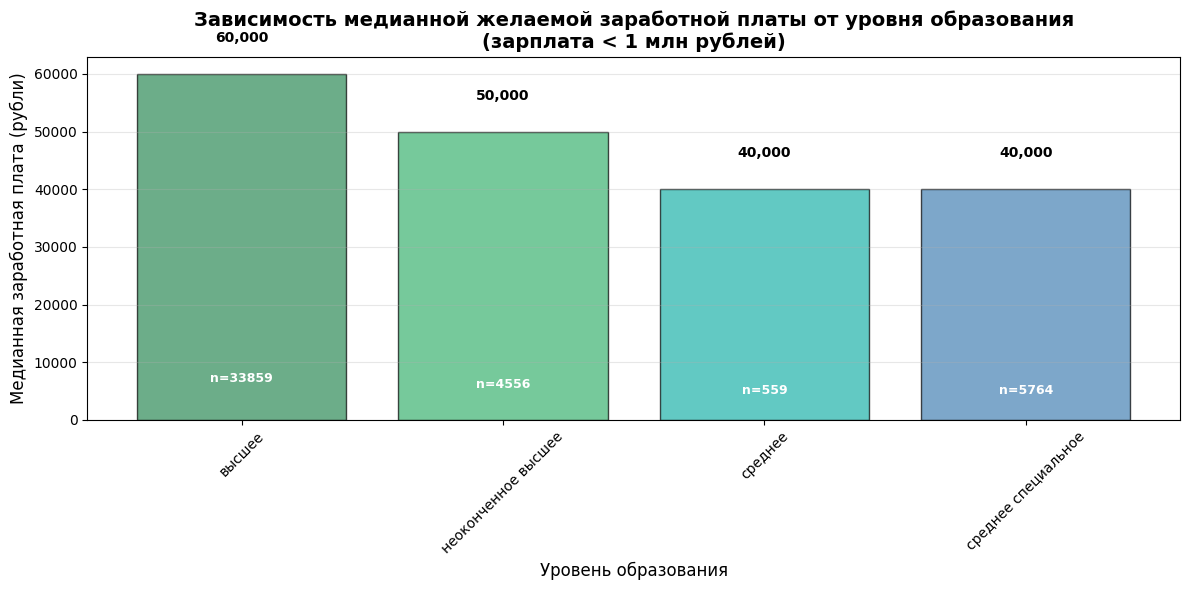

In [ ]:
filtered_data = df_processed[df_processed['ЗП (руб)'] < 1000000]

calculate_median_salary_lambda = lambda data: (
    data.groupby('Образование')['ЗП (руб)'].median().sort_values(ascending=False)
)

median_salaries = calculate_median_salary_lambda(filtered_data)

plt.figure(figsize=(12, 6))
colors = ['#2E8B57', '#3CB371', '#20B2AA', '#4682B4', '#6A5ACD']

education_list = list(median_salaries.index)
salary_list = list(median_salaries.values)

bars = plt.bar(education_list, salary_list, color=colors, alpha=0.7, edgecolor='black')

for i, (education, salary) in enumerate(zip(education_list, salary_list)):
    plt.text(i, salary + 5000, f'{salary:,.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.xlabel('Уровень образования', fontsize=12)
plt.ylabel('Медианная заработная плата (рубли)', fontsize=12)
plt.title('Зависимость медианной желаемой заработной платы от уровня образования\n(зарплата < 1 млн рублей)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3, axis='y')

count_by_education = filtered_data['Образование'].value_counts()
for i, education in enumerate(education_list):
    count = count_by_education[education]
    plt.text(i, salary_list[i] * 0.1, f'n={count}', ha='center', va='bottom', 
             fontsize=9, color='white', fontweight='bold')

plt.tight_layout()
plt.show()



На графике представлена зависимость медианной желаемой ЗП от уровня образования, включающему четыре уровня: высшее, неоконченное высшее, среднее и среднее специальное. По построенному графику наглядно видно, что наибольшей уровень желаемой заработной платы в медианном показателе соотносится с высшим образованием — 50 000, а наименьший сразу двум уровням образования, среднему и среднему специальному — 40 000. Учитывая эту разницу, уровень образования является важным признаком при прогнозировании заработной платы.

5. Постройте диаграмму, которая показывает распределение желаемой заработной платы (**"ЗП (руб)"**) в зависимости от города (**"Город"**). Используйте для диаграммы данные о резюме, где желая заработная плата меньше 1 млн рублей.
*Сделайте выводы по полученной диаграмме: как соотносятся медианные уровни желаемой заработной платы и их размах в городах? Как вы считаете, важен ли признак города при прогнозировании заработной платы?*

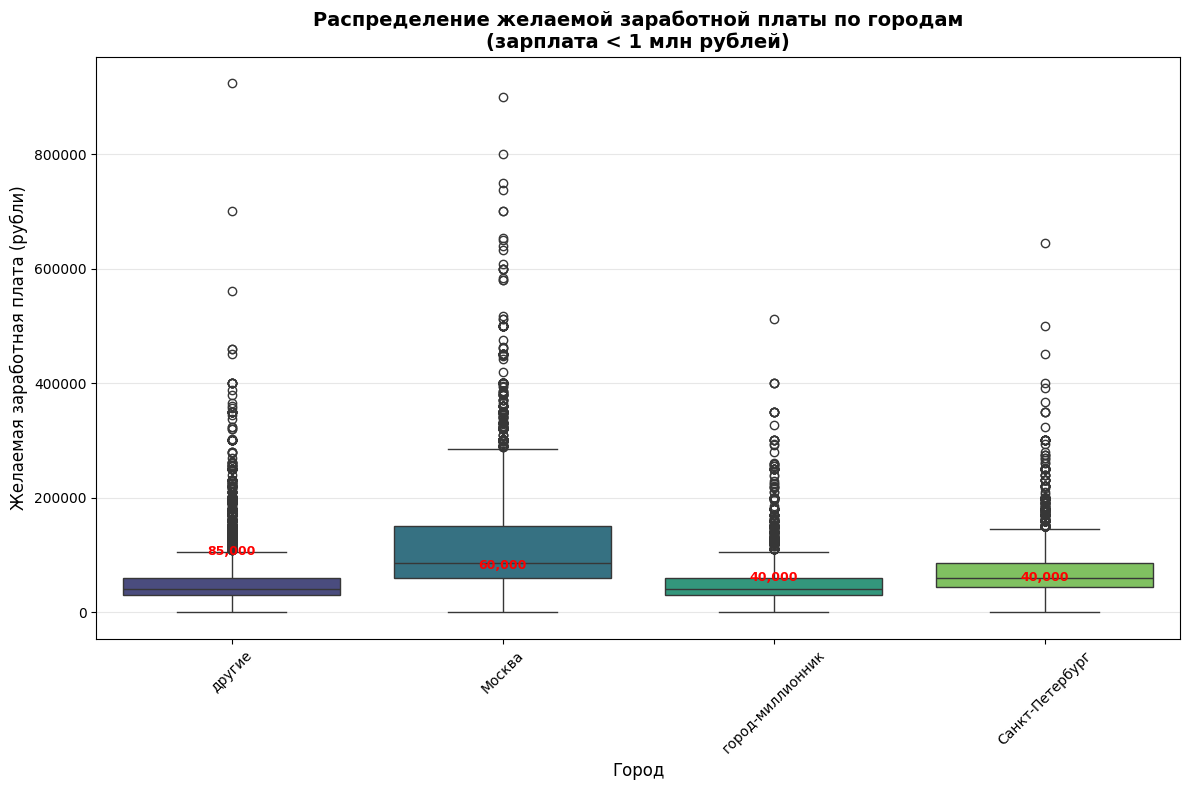

Город с наибольшей желаемой зарплатой (~924 тыс. рублей): Москва


In [ ]:
filtered_data = df_processed[df_processed['ЗП (руб)'] < 1000000]

calculate_city_stats_lambda = lambda data: (
    data.groupby('Город')['ЗП (руб)'].agg(['median', 'min', 'max', 'count']).round(2)
    .sort_values('median', ascending=False)
)

find_max_median_city_lambda = lambda stats: (
    stats.index[0], stats.iloc[0]['median']
)

city_stats = calculate_city_stats_lambda(filtered_data)
max_city, max_salary = find_max_median_city_lambda(city_stats)

plt.figure(figsize=(12, 8))
sns.boxplot(data=filtered_data, x='Город', y='ЗП (руб)', hue='Город', palette='viridis', legend=False)
plt.xticks(rotation=45)
plt.xlabel('Город', fontsize=12)
plt.ylabel('Желаемая заработная плата (рубли)', fontsize=12)
plt.title('Распределение желаемой заработной платы по городам\n(зарплата < 1 млн рублей)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')

for i, city in enumerate(city_stats.index):
    median_val = city_stats.loc[city, 'median']
    plt.text(i, median_val + 10000, f'{median_val:,.0f}', ha='center', va='bottom', 
             fontsize=9, fontweight='bold', color='red')

plt.tight_layout()
plt.show()

city_stats = filtered_data.groupby('Город')['ЗП (руб)'].agg(['median', 'min', 'max', 'count']).round(2)
city_stats_sorted = city_stats.sort_values('median', ascending=False)

# Находим город с наибольшей медианной зарплатой
max_median_city = city_stats_sorted.index[0]
max_median_salary = city_stats_sorted.iloc[0]['median']

print(f"Город с наибольшей желаемой зарплатой (~924 тыс. рублей): {max_median_city}")


На графике представлена зависимость желаемой заработной платы от города, в котором проживает соискатель. Согласно построенному графику, уровн медианной заработной платы и их размах распределяются по городам следующим образом: Москва — 85 000 рублей (с размахом от 1 до 900000 рублей), Санкт-Петербург — 60 000 рублей (с размахом от 1 до 645 171 рублей), города-миллионники — 40 000 рублей (с размахом от 1 до 511682 тысячи) и другие города — 40 000 рублей (с размухом от 1 до 923 983 рублей). Наибольший размах наблюдается в городах категории другие, а наименьший — в городах-миллионниках. Разница между максимальной и минимальной медианной зарплатой составляет 45 000 рублей, что наталкивает на вывод о важности города как фактора при прогнозировании заработной платы. 

6. Постройте **многоуровневую столбчатую диаграмму**, которая показывает зависимость медианной заработной платы (**"ЗП (руб)"**) от признаков **"Готовность к переезду"** и **"Готовность к командировкам"**. Проанализируйте график, сравнив уровень заработной платы в категориях.

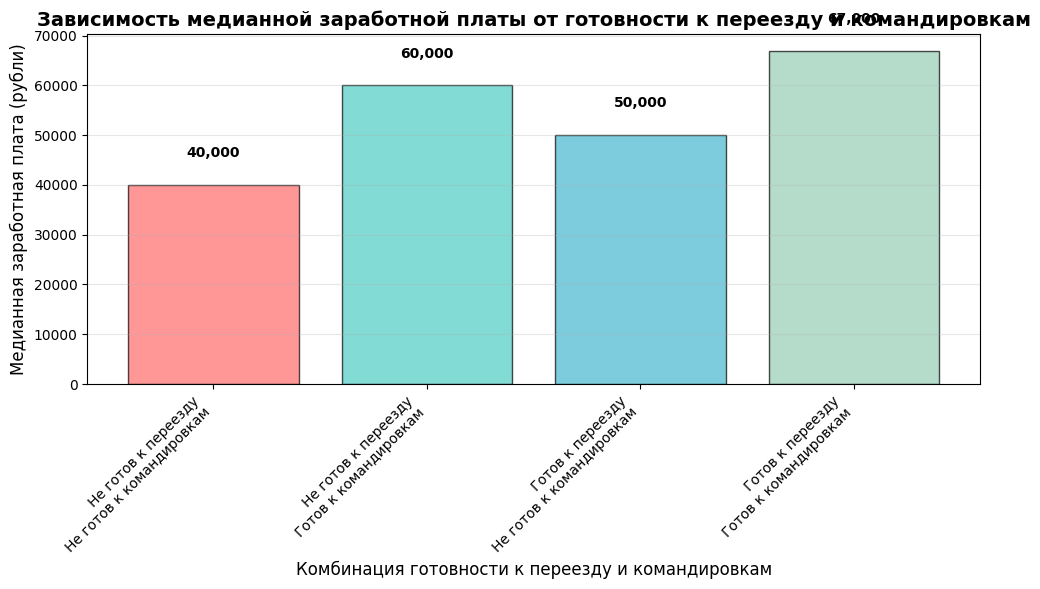

Медианная зарплата готовых к переезду и командировкам: 67,000 рублей
В тысячах рублей: 67


In [ ]:
calculate_median_salary_grouped_lambda = lambda data: (
    data.groupby(['Готовность к переезду', 'Готовность к командировкам'])['ЗП (руб)']
    .median().round(2)
)

median_salaries = calculate_median_salary_grouped_lambda(df_processed)

plt.figure(figsize=(10, 6))

categories = [
    'Не готов к переезду\nНе готов к командировкам',
    'Не готов к переезду\nГотов к командировкам', 
    'Готов к переезду\nНе готов к командировкам',
    'Готов к переезду\nГотов к командировкам'
]

values = [
    median_salaries[(False, False)],
    median_salaries[(False, True)],
    median_salaries[(True, False)], 
    median_salaries[(True, True)]
]

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
bars = plt.bar(categories, values, color=colors, alpha=0.7, edgecolor='black')

for i, (category, value) in enumerate(zip(categories, values)):
    plt.text(i, value + 5000, f'{value:,.0f}', ha='center', va='bottom', 
             fontsize=10, fontweight='bold')

plt.xlabel('Комбинация готовности к переезду и командировкам', fontsize=12)
plt.ylabel('Медианная заработная плата (рубли)', fontsize=12)
plt.title('Зависимость медианной заработной платы от готовности к переезду и командировкам', 
          fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

both_ready_salary = median_salaries[(True, True)]
both_ready_thousands = round(both_ready_salary / 1000)

print(f"Медианная зарплата готовых к переезду и командировкам: {both_ready_salary:,.0f} рублей")
print(f"В тысячах рублей: {both_ready_thousands}")


На графике представлена зависимость желаемой заработной платы и готовности к переезду и\или командировкам. Медианные зарплаты ко комбинации двух признаков выглядят следующим образом — не готов к переезду, не готов к командировкам — 40,000 рублей; не готов к переезду, готов к командировкам — 60,000 рублей; готов к переезду, не готов к командировкам — 50,000 рублей; готов к переезду, готов к командировкам — 67,000 рублей. Готовность к переезду оказывает большее влияние на зарплату, чем готовность к командировкам. Наибольший показатель заработной платы соотносится с готовностью и к переездку, и к командировкам, а наименьший — с неготовностью к обоим факторам. 



7. Постройте сводную таблицу, иллюстрирующую зависимость **медианной** желаемой заработной платы от возраста (**"Возраст"**) и образования (**"Образование"**). На полученной сводной таблице постройте **тепловую карту**. Проанализируйте тепловую карту, сравнив показатели внутри групп.

C:\Users\asus\AppData\Local\Temp\ipykernel_856\2398775011.py:7: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  data.pivot_table(


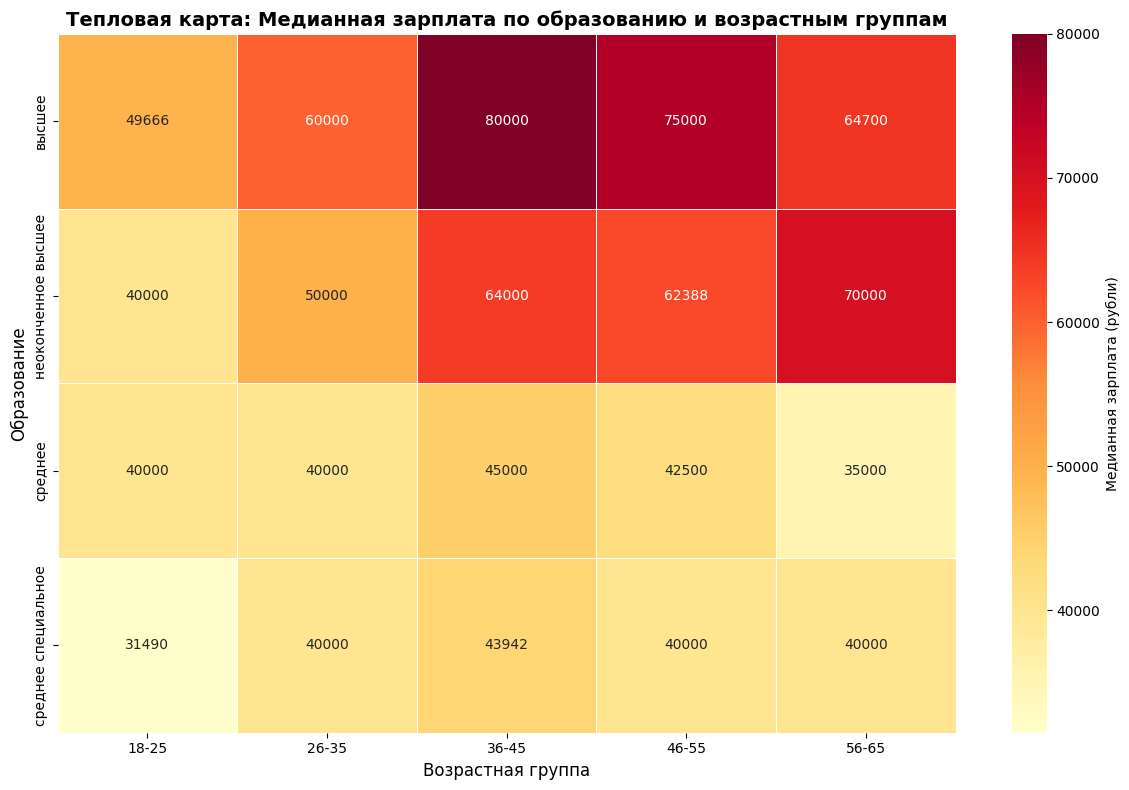

In [ ]:
age_bins = [18, 25, 35, 45, 55, 65]
age_labels = ['18-25', '26-35', '36-45', '46-55', '56-65']
df_processed['Возрастная_группа'] = pd.cut(df_processed['Возраст'], bins=age_bins, labels=age_labels)

create_pivot_lambda = lambda data: (
    data.pivot_table(
        values='ЗП (руб)',
        index='Образование',
        columns='Возрастная_группа',
        aggfunc='median',
        fill_value=0
    )
)

pivot_table = create_pivot_lambda(df_processed)

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_table, annot=True, fmt='.0f', cmap='YlOrRd', 
            linewidths=0.5, linecolor='white', cbar_kws={'label': 'Медианная зарплата (рубли)'})
plt.title('Тепловая карта: Медианная зарплата по образованию и возрастным группам', 
          fontsize=14, fontweight='bold')
plt.xlabel('Возрастная группа', fontsize=12)
plt.ylabel('Образование', fontsize=12)
plt.tight_layout()
plt.show()
df_processed = df_processed.drop(['Возрастная_группа'], axis=1)
analyze_career_growth_lambda = lambda pivot: (
    pivot.apply(lambda row: (row.iloc[-1] - row.iloc[0]) / row.iloc[0] * 100, axis=1)
    .sort_values(ascending=False)
)

career_growth = analyze_career_growth_lambda(pivot_table)

График показывает зависимость влияние возраста и ступени образования на динамику прироста заработной платы. Процентный рост зарплаты от младшей к старшей возрастной группе: неоконченное высшее: 30.3%; высшее: 75.о%; среднее специальное: 27.0%; среднее: -12.5%. Наибольший абсолютный рост зарплаты принадлежит соискателям с высшим образованием. 



8. Постройте **диаграмму рассеяния**, показывающую зависимость опыта работы (**"Опыт работы (месяц)"**) от возраста (**"Возраст"**). Опыт работы переведите из месяцев в года, чтобы признаки были в едином масштабе. Постройте на графике дополнительно прямую, проходящую через точки (0, 0) и (100, 100). Данная прямая соответствует значениям, когда опыт работы равен возрасту человека. Точки, лежащие на этой прямой и выше нее - аномалии в наших данных (опыт работы больше либо равен возрасту соискателя)

,Ищет работу на должность:,Последнее/нынешнее место работы,Последняя/нынешняя должность,Авто,Образование,Пол,Возраст,Опыт работы (месяц),Город,Готовность к переезду,...,Занятость_проектная работа,Занятость_волонтерство,Занятость_стажировка,График_полный день,График_сменный график,График_гибкий график,График_удалённая работа,График_вахтовый метод,ЗП (руб),Опыт_лет


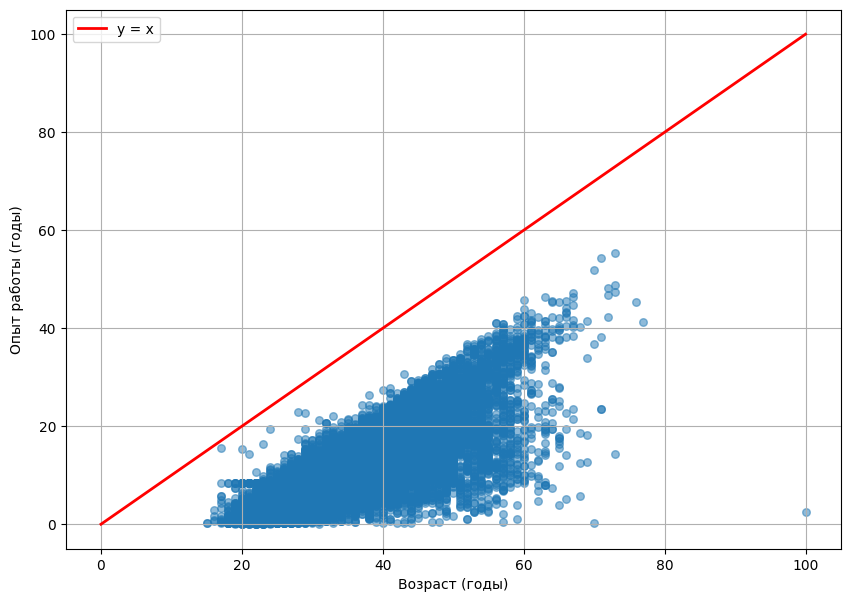

In [33]:
df_raw = df_processed.dropna(subset=["Возраст", "Опыт работы (месяц)"]).copy()
experience_years = df_raw["Опыт работы (месяц)"] / 12
df_above = df_raw[experience_years > df_raw["Возраст"]]

display(df_above.head(20))

plt.figure(figsize=(10, 7))
plt.scatter(df_raw["Возраст"], experience_years, alpha=0.5, s=30)

max_age = df_raw["Возраст"].max()
plt.plot([0, max_age], [0, max_age],
         color='red', linewidth=2, label='y = x')

plt.xlabel("Возраст (годы)")
plt.ylabel("Опыт работы (годы)")
plt.legend()
plt.grid(True)
plt.show()

На графике изображена зависимость опыта работы от возраста. Большая часть значений соответствует реальности, но точки, расположенные выше прямой в красной зоне, являются аномалиями, говорящими о том, что опыт работы соискателя превышает его возраст. Таких точек семь, данные вбросы значительно влияют на восприятие информации. 

**Дополнительные баллы**

Для получения 2 дополнительных баллов по разведывательному анализу постройте еще два любых содержательных графика или диаграммы, которые помогут проиллюстрировать влияние признаков/взаимосвязь между признаками/распределения признаков. Приведите выводы по ним. Желательно, чтобы в анализе участвовали признаки, которые мы создавали ранее в разделе "Преобразование данных".


<Figure size 1400x800 with 0 Axes>

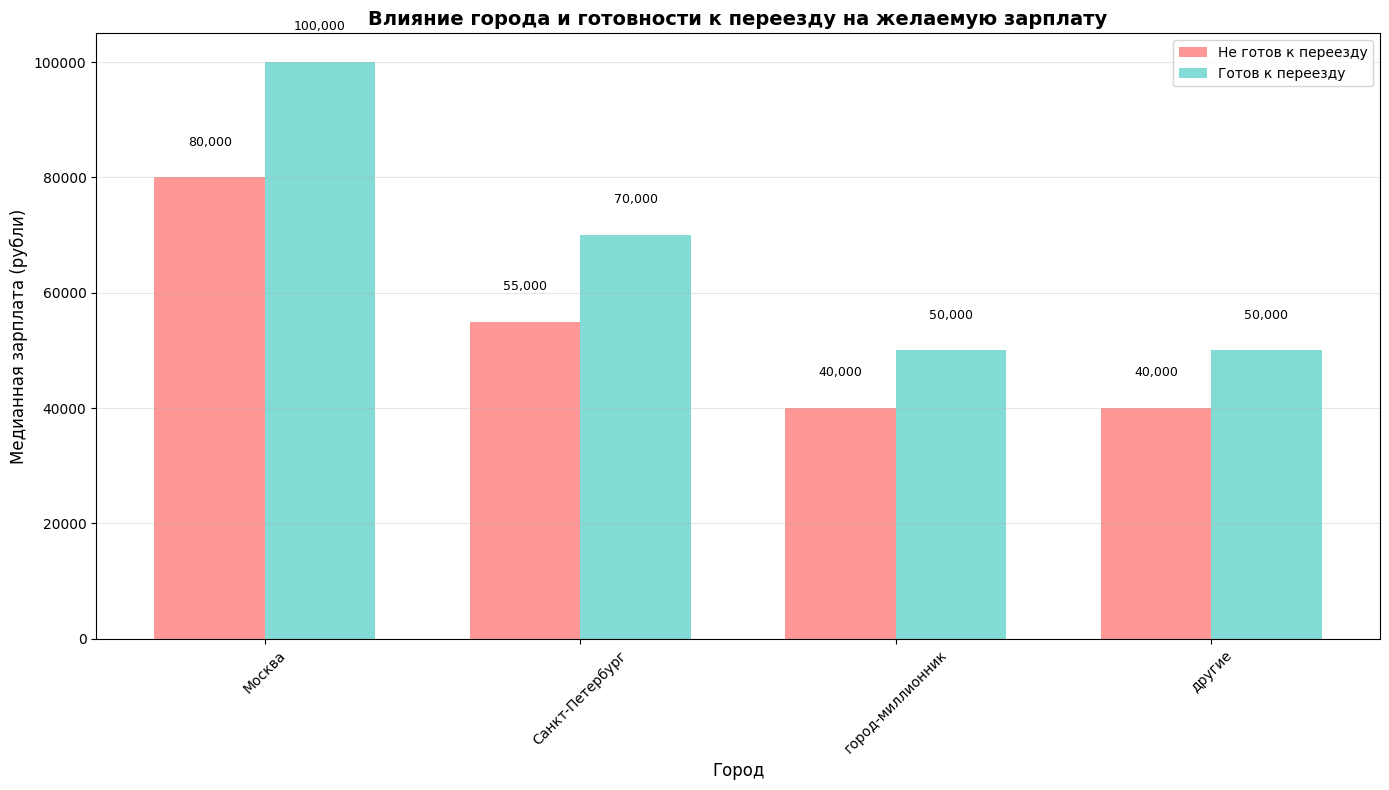

C:\Users\asus\AppData\Local\Temp\ipykernel_856\4089037507.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=experience_data, x='Образование', y='Опыт работы (месяц)',


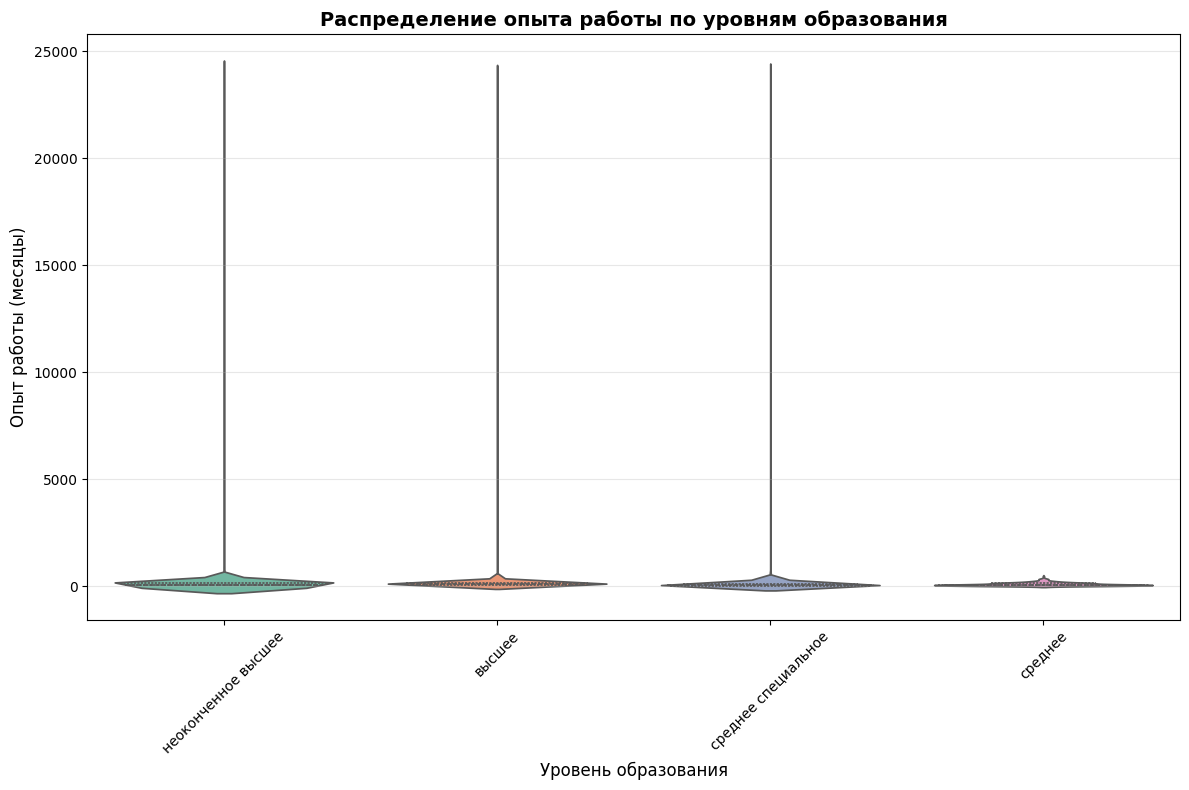

In [ ]:
# ГРАФИК 1: Влияние города и готовности к переезду на зарплату
plt.figure(figsize=(14, 8))
prepare_city_relocation_data_lambda = lambda data: (
    data.groupby(['Город', 'Готовность к переезду'])['ЗП (руб)']
    .median()
    .unstack()
)

city_relocation_data = prepare_city_relocation_data_lambda(df_processed)

x = np.arange(len(city_relocation_data.index))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 8))
bars1 = ax.bar(x - width/2, city_relocation_data[False], width, label='Не готов к переезду', alpha=0.7, color='#FF6B6B')
bars2 = ax.bar(x + width/2, city_relocation_data[True], width, label='Готов к переезду', alpha=0.7, color='#4ECDC4')

ax.set_xlabel('Город', fontsize=12)
ax.set_ylabel('Медианная зарплата (рубли)', fontsize=12)
ax.set_title('Влияние города и готовности к переезду на желаемую зарплату', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(city_relocation_data.index, rotation=45)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 5000,
                f'{height:,.0f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# ГРАФИК 2: Распределение опыта работы по уровням образования
plt.figure(figsize=(12, 8))

prepare_experience_education_data_lambda = lambda data: (
    data[['Образование', 'Опыт работы (месяц)']].dropna()
)

experience_data = prepare_experience_education_data_lambda(df_processed)

sns.violinplot(data=experience_data, x='Образование', y='Опыт работы (месяц)', 
               palette='Set2', inner='quartile')
plt.xticks(rotation=45)
plt.xlabel('Уровень образования', fontsize=12)
plt.ylabel('Опыт работы (месяцы)', fontsize=12)
plt.title('Распределение опыта работы по уровням образования', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

На первом графике, гистограмме, изображено влияние зависимости города и готовности к командировке и/или переезду на желаемую заработную плату. Готовность к переезду положительно влияет на зарплату во всех городах. Наибольшая разница в зарплате между готовыми и не готовыми к переезду наблюдается в Москве: +20,000 руб. В Москве и Санкт-Петербурге разница меньше, вероятно из-за уже высоких зарплат. В регионах готовность к переезду дает больший прирост к ожиданиям по зарплате. 
На втором графике, коробчатой диаграмме, изображено распределение опыта работы по уровням образования. Наибольший медианный опыт у соискателей с высшим и неоконченным высшим образованием. Наименьший разброс опыта работы у соискателей со средним образованием. Медианный опыт работы по образованиям (в годах): высшее: 9.2 лет; неоконченное высшее: 6.5 лет; среднее: 6.1 лет; среднее специальное: 5.7 лет.

# Очистка данных

1. Начнем с дубликатов в наших данных. Найдите **полные дубликаты** в таблице с резюме и удалите их. 

In [ ]:
full_dups = df_processed.duplicated().sum()
df = df_processed.drop_duplicates().reset_index(drop=True)

2. Займемся пропусками. Выведите информацию **о числе пропусков** в столбцах. 

In [ ]:
missing_info = df_processed.isna().sum()
print(missing_info)
print("Пропусков в 'Опыт работы (месяц)':", df_processed['Опыт работы (месяц)'].isna().sum())

Ищет работу на должность:            0
Последнее/нынешнее место работы      1
Последняя/нынешняя должность         2
Авто                                 0
Образование                          0
Пол                                  0
Возраст                              0
Опыт работы (месяц)                170
Город                                0
Готовность к переезду                0
Готовность к командировкам           0
Занятость_полная занятость           0
Занятость_частичная занятость        0
Занятость_проектная работа           0
Занятость_волонтерство               0
Занятость_стажировка                 0
График_полный день                   0
График_сменный график                0
График_гибкий график                 0
График_удалённая работа              0
График_вахтовый метод                0
ЗП (руб)                             0
dtype: int64
Пропусков в 'Опыт работы (месяц)': 170


3. Итак, у нас есть пропуски в 3ех столбцах: **"Опыт работы (месяц)"**, **"Последнее/нынешнее место работы"**, **"Последняя/нынешняя должность"**. Поступим следующим образом: удалите строки, где есть пропуск в столбцах с местом работы и должностью. Пропуски в столбце с опытом работы заполните **медианным** значением.

In [ ]:
df_processed = df_processed.dropna(subset=['Последнее/нынешнее место работы', 'Последняя/нынешняя должность'])
median_exp = df_processed['Опыт работы (месяц)'].median()
df_processed['Опыт работы (месяц)'] = df_processed['Опыт работы (месяц)'].fillna(median_exp)

mean_after_fill = round(df['Опыт работы (месяц)'].mean())
print("Среднее после заполнения:", mean_after_fill)

Среднее после заполнения: 128


4. Мы добрались до ликвидации выбросов. Сначала очистим данные вручную. Удалите резюме, в которых указана заработная плата либо выше 1 млн. рублей, либо ниже 1 тыс. рублей.

In [ ]:
salary_outliers = df_processed[(df_processed['ЗП (руб)'] < 1000) | (df_processed['ЗП (руб)'] > 1_000_000)]
print("Выбросов по зарплате:", len(salary_outliers))
df_processed = df_processed[(df_processed['ЗП (руб)'] >= 1000) & (df_processed['ЗП (руб)'] <= 1_000_000)]

Выбросов по зарплате: 89


5. В процессе разведывательного анализа мы обнаружили резюме, в которых **опыт работы в годах превышал возраст соискателя**. Найдите такие резюме и удалите их из данных


In [ ]:
df_processed['Опыт_лет'] = df_processed['Опыт работы (месяц)'] / 12
exp_age_outliers = df_processed[df_processed['Опыт_лет'] > df_processed['Возраст']]
print("Выбросов, где опыт > возраст:", len(exp_age_outliers))
df_processed = df_processed[df_processed['Опыт_лет'] <= df_processed['Возраст']]


Выбросов, где опыт > возраст: 33


6. В результате анализа мы обнаружили потенциальные выбросы в признаке **"Возраст"**. Это оказались резюме людей чересчур преклонного возраста для поиска работы. Попробуйте построить распределение признака в **логарифмическом масштабе**. Добавьте к графику линии, отображающие **среднее и границы интервала метода трех сигм**. Напомним, сделать это можно с помощью метода axvline. Например, для построение линии среднего будет иметь вид:

`histplot.axvline(log_age.mean(), color='k', lw=2)`

В какую сторону асимметрично логарифмическое распределение? Напишите об этом в комментарии к графику.
Найдите выбросы с помощью метода z-отклонения и удалите их из данных, используйте логарифмический масштаб. Давайте сделаем послабление на **1 сигму** (возьмите 4 сигмы) в **правую сторону**.

Выведите таблицу с полученными выбросами и оцените, с каким возрастом соискатели попадают под категорию выбросов?


Найдено выбросов по возрасту (z > 3): 111


,Возраст
152,72
850,71
1064,63
1251,63
1430,64
...,...
43381,68
43653,63
44363,70
44414,65


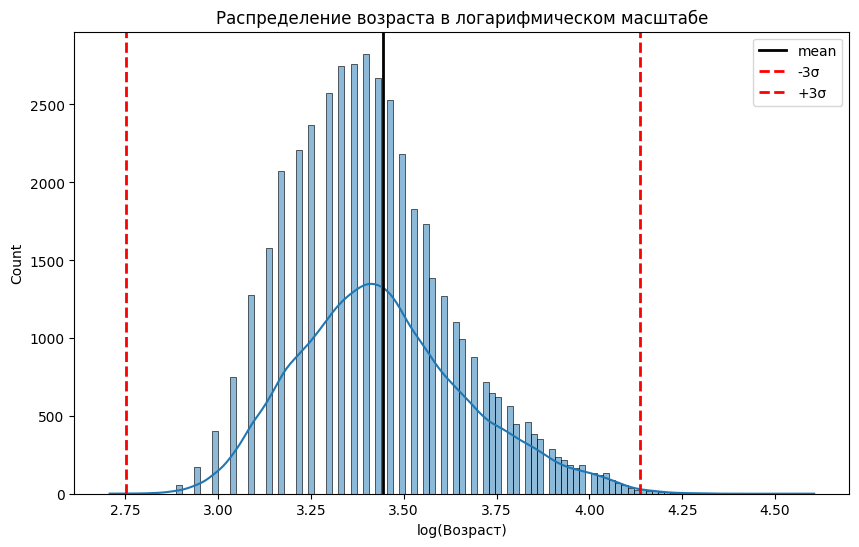

In [26]:
age = df_processed['Возраст']
age = age[age > 0]  

log_age = np.log(age)

mu = log_age.mean()
sigma = log_age.std()

left_border = mu - 3 * sigma
right_border = mu + 3 * sigma

z_scores = (log_age - mu) / sigma
outliers = df_processed.loc[z_scores[z_scores > 3].index, ['Возраст']]

print("\nНайдено выбросов по возрасту (z > 3):", len(outliers))
display(outliers)

plt.figure(figsize=(10, 6))
histplot = sns.histplot(log_age, kde=True)


histplot.axvline(mu, color='black', lw=2, label='mean')
histplot.axvline(left_border, color='red', lw=2, linestyle='--', label='-3σ')
histplot.axvline(right_border, color='red', lw=2, linestyle='--', label='+3σ')

plt.title("Распределение возраста в логарифмическом масштабе")
plt.xlabel("log(Возраст)")
plt.ylabel("Count")
plt.legend()
plt.show()

Логарифмическое распределение возраста является асимметричным вправо. Это означает, что в данных преобладают более молодые соискатели, а пожилые составляют "хвост" распределения. Такая асимметрия типична для возрастных распределений на рынке труда, где большинство соискателей - люди активного трудоспособного возраста. Согласно методу z-отклонения с границей в, выбросами считаются соискатели старше примерно 68-70 лет. Эти возрастные группы являются статистически нетипичными для рынка труда и могут искажать анализ.